### การวัด รายได้ ต่อเดือน ปี 2023

Total Price , Quantity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

In [2]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

### Revenue ==================================================

#### 1) AOV Per Month (ค่าเฉลี่ยรายได้ต่อเดือน)

###### คํานวนจาก logic delivery= product delivered & totalPrice 

In [3]:

revenue_per_month = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Delivered")]
    .groupby(["OrderID", "Month_name"])["Total Price"]
    .sum()
    .reset_index()
)

avg_revenue_per_month = (
    revenue_per_month
    .groupby("Month_name")["Total Price"]
    .mean()
    .reindex(month_order)   # January -> December
)

In [4]:
print(avg_revenue_per_month)

Month_name
January      1330.666667
February     1015.757576
March        1204.761905
April        1132.727273
May          1209.000000
June         1176.363636
July         1378.571429
August        738.500000
September    1896.875000
October       951.153846
November     2103.225806
December     1548.275862
Name: Total Price, dtype: float64


#### 2) Total Revenue Per Month (ผลรวมรายได้ต่อเดือน)

In [5]:
print(revenue_per_month.groupby("Month_name")["Total Price"].sum().sort_values(ascending=False))

Month_name
November     65200
December     44900
January      39920
June         38820
July         38600
February     33520
September    30350
March        25300
April        24920
October      24730
May          24180
August       14770
Name: Total Price, dtype: int64


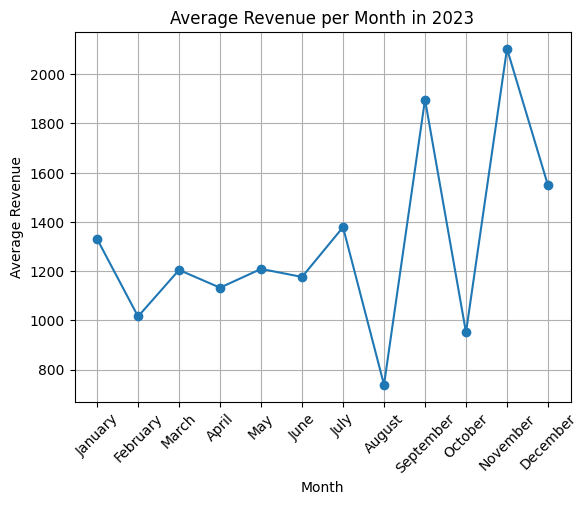

In [6]:
# Revenue Trend per Month in 2023
plt.plot(avg_revenue_per_month.index, avg_revenue_per_month.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.title("Average Revenue per Month in 2023")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Growth/Quantity ==================================================

#### 1) Increase/Decrease of Total Revenue (Deliveried Order) per Month

###### คํานวนจาก logic delivery= product delivered & totalPrice 

In [7]:
# ...existing code...
monthly_quantity = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Delivered")]
    .groupby("Month_name")["Quantity"]
    .sum()
    .reindex(month_order)   # January -> December
)

monthly_growth = monthly_quantity.pct_change() * 100
# ...existing code...

In [8]:
print(monthly_quantity)

Month_name
January      101
February      99
March         71
April         62
May           59
June          92
July          77
August        44
September     53
October       84
November      95
December      90
Name: Quantity, dtype: int64


#### 2) Increase/Decrease of Total Average Revenue (Deliveried Order) per Month

In [9]:
print(monthly_growth)

Month_name
January            NaN
February     -1.980198
March       -28.282828
April       -12.676056
May          -4.838710
June         55.932203
July        -16.304348
August      -42.857143
September    20.454545
October      58.490566
November     13.095238
December     -5.263158
Name: Quantity, dtype: float64


### Trending ==================================================

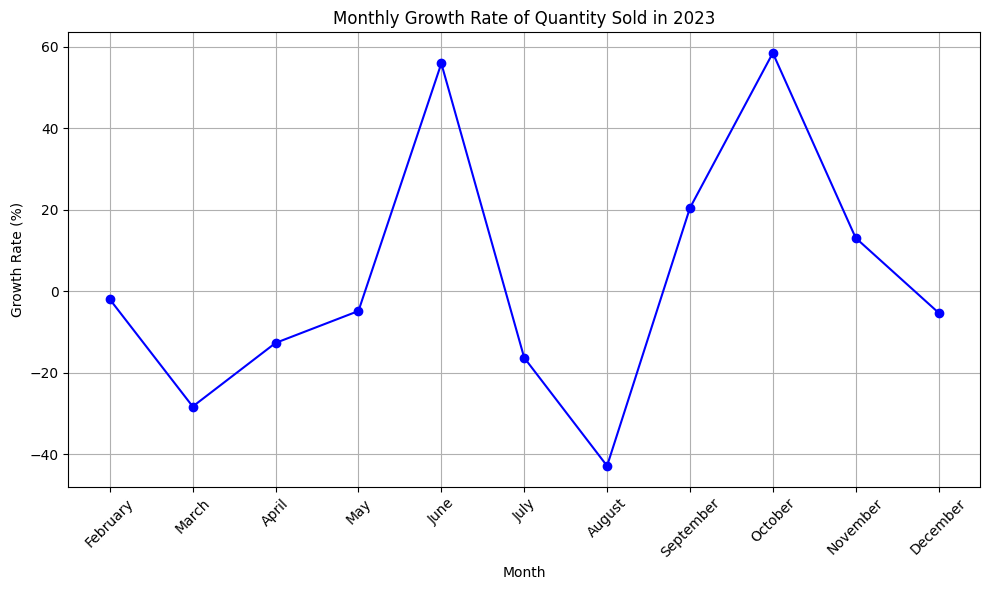

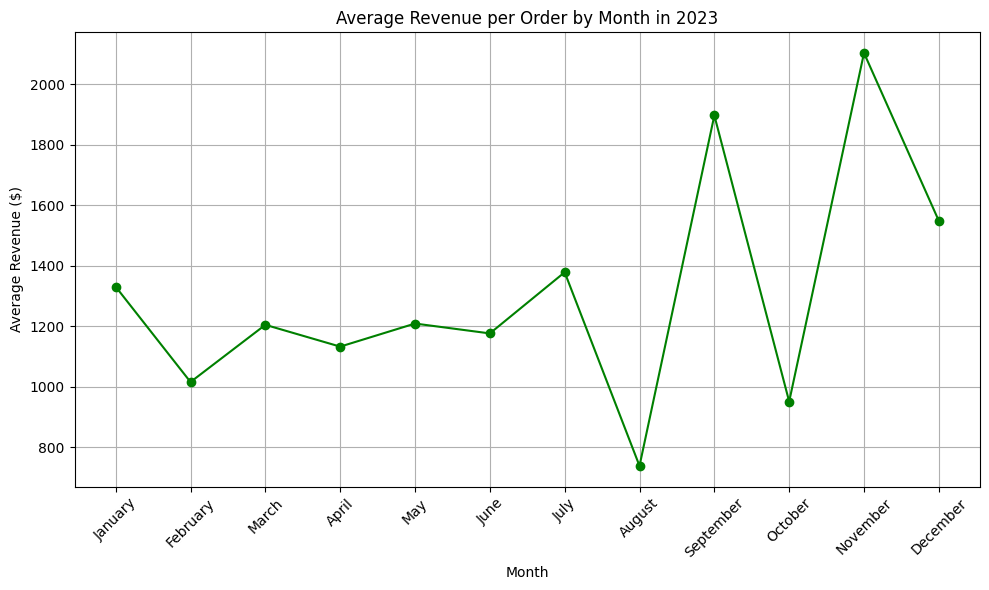

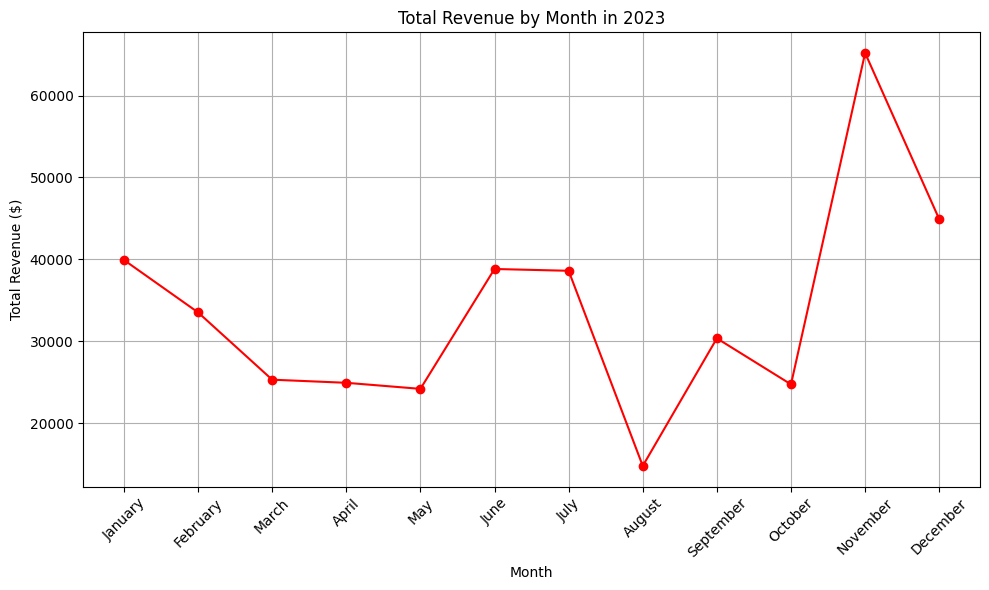

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_growth.index, monthly_growth.values, marker='o', linestyle='-', color='b')
plt.title('Monthly Growth Rate of Quantity Sold in 2023')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(avg_revenue_per_month.index, avg_revenue_per_month.values, marker='o', linestyle='-', color='g')
plt.title('Average Revenue per Order by Month in 2023')
plt.xlabel('Month')
plt.ylabel('Average Revenue ($)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
plt.plot(
    revenue_per_month.groupby("Month_name")["Total Price"].sum().reindex(month_order).index,
    revenue_per_month.groupby("Month_name")["Total Price"].sum().reindex(month_order).values,
    marker='o', linestyle='-', color='r'
)
plt.title('Total Revenue by Month in 2023')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

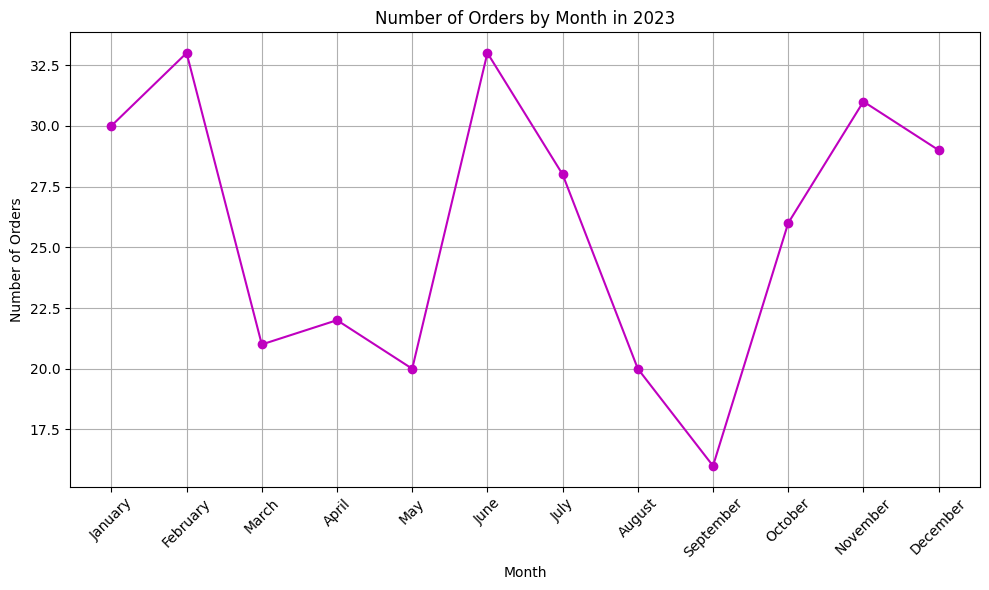

In [12]:
# Visualize Order count trend
order_count_per_month = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Delivered")]
    .groupby("Month_name")["OrderID"]
    .nunique()
    .reindex(month_order)   # January -> December
)
plt.figure(figsize=(10, 6))
plt.plot(order_count_per_month.index, order_count_per_month.values, marker='o', linestyle='-', color='m')
plt.title('Number of Orders by Month in 2023')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

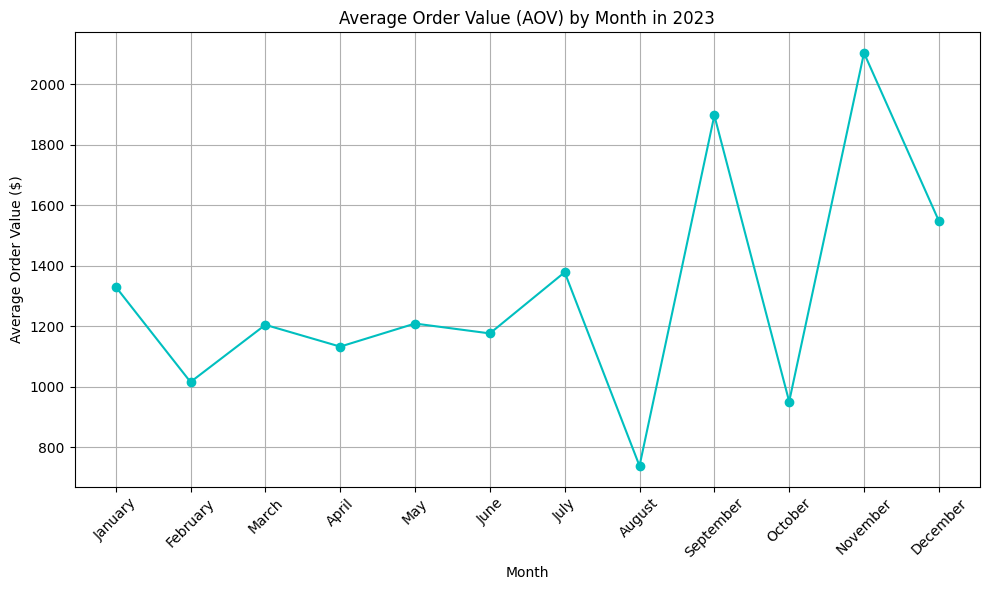

In [13]:
# AOV Trend per Month in 2023
aov_per_month = revenue_per_month.groupby("Month_name")["Total Price"].mean().reindex(month_order)
plt.figure(figsize=(10, 6))
plt.plot(aov_per_month.index, aov_per_month.values, marker='o', linestyle='-', color='c')
plt.title('Average Order Value (AOV) by Month in 2023')
plt.xlabel('Month')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
